In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("learntwin_student_interactions.csv")

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (10000, 10)

Columns:
['student_id', 'attempt', 'question_id', 'concept', 'difficulty', 'correct', 'time_gap_days', 'days_since_practice', 'timestamp', 'knowledge_state']


,student_id,attempt,question_id,concept,difficulty,correct,time_gap_days,days_since_practice,timestamp,knowledge_state
0,S001,1,Q043,RIGHT JOIN,0.724,0,3.007,3.007,3.007,0.3574
1,S001,2,Q452,RIGHT JOIN,0.577,0,1.471,1.471,4.478,0.3103
2,S001,3,Q022,UNION,0.499,1,1.675,6.154,6.154,0.3849
3,S001,4,Q007,WHERE,0.380,1,0.563,6.717,6.717,0.4015
4,S001,5,Q114,STORED PROCEDURES,0.598,1,2.683,9.400,9.400,0.1345


In [5]:
print("Dataset shape:", df.shape)
print(df.columns.tolist())

Dataset shape: (10000, 10)
['student_id', 'attempt', 'question_id', 'concept', 'difficulty', 'correct', 'time_gap_days', 'days_since_practice', 'timestamp', 'knowledge_state']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           10000 non-null  str    
 1   attempt              10000 non-null  int64  
 2   question_id          10000 non-null  str    
 3   concept              10000 non-null  str    
 4   difficulty           10000 non-null  float64
 5   correct              10000 non-null  int64  
 6   time_gap_days        10000 non-null  float64
 7   days_since_practice  10000 non-null  float64
 8   timestamp            10000 non-null  float64
 9   knowledge_state      10000 non-null  float64
dtypes: float64(5), int64(2), str(3)
memory usage: 781.4 KB


## 4.2 — Sort the student interactions

In [6]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values(
    by=["student_id", "timestamp"]
).reset_index(drop=True)

print(df.head(10))

  student_id  attempt question_id            concept  difficulty  correct  \
0       S001        1        Q043         RIGHT JOIN       0.724        0   
1       S001        2        Q452         RIGHT JOIN       0.577        0   
2       S001        3        Q022              UNION       0.499        1   
3       S001        4        Q007              WHERE       0.380        1   
4       S001        5        Q114  STORED PROCEDURES       0.598        1   
5       S001        6        Q210           GROUP BY       0.475        0   
6       S001        7        Q481           TRIGGERS       0.686        0   
7       S001        8        Q331  STORED PROCEDURES       0.731        0   
8       S001        9        Q390           GROUP BY       0.446        1   
9       S001       10        Q334         SUBQUERIES       0.603        0   

   time_gap_days  days_since_practice                     timestamp  \
0          3.007                3.007 1970-01-01 00:00:00.000000003   
1         

## 4.3 — Understand days_since_practice

In [7]:
print(df["days_since_practice"].describe())

count    10000.000000
mean        24.154244
std         23.153417
min          0.006000
25%          7.391250
50%         17.105500
75%         33.868250
max        171.227000
Name: days_since_practice, dtype: float64


In [8]:
print(
    df[[
        "student_id",
        "concept",
        "correct",
        "time_gap_days",
        "days_since_practice"
    ]].head(20)
)

   student_id              concept  correct  time_gap_days  \
0        S001           RIGHT JOIN        0          3.007   
1        S001           RIGHT JOIN        0          1.471   
2        S001                UNION        1          1.675   
3        S001                WHERE        1          0.563   
4        S001    STORED PROCEDURES        1          2.683   
5        S001             GROUP BY        0          0.427   
6        S001             TRIGGERS        0          1.194   
7        S001    STORED PROCEDURES        0          0.319   
8        S001             GROUP BY        1          0.610   
9        S001           SUBQUERIES        0          1.395   
10       S001            LEFT JOIN        0          0.505   
11       S001           RIGHT JOIN        0          1.698   
12       S001                VIEWS        1          0.702   
13       S001             ORDER BY        1          2.305   
14       S001                VIEWS        0          0.333   
15      

## 4.4 — Create previous concept performance

In [9]:
concept_group = df.groupby(
    ["student_id", "concept"]
)

df["concept_prior_correct"] = (
    concept_group["correct"].cumsum()
    - df["correct"]
)

df["concept_prior_attempts"] = (
    concept_group.cumcount()
)

In [10]:
df["concept_prior_accuracy"] = np.where(
    df["concept_prior_attempts"] > 0,
    df["concept_prior_correct"] /
    df["concept_prior_attempts"],
    0.5
)

## 4.5 — Create previous student performance

In [11]:
df["student_prior_correct"] = (
    df.groupby("student_id")["correct"].cumsum()
    - df["correct"]
)

df["student_prior_attempts"] = (
    df.groupby("student_id").cumcount()
)

df["student_prior_accuracy"] = np.where(
    df["student_prior_attempts"] > 0,
    df["student_prior_correct"] /
    df["student_prior_attempts"],
    0.5
)

In [12]:
df[[
    "student_id",
    "concept",
    "correct",
    "student_prior_accuracy",
    "concept_prior_accuracy",
    "days_since_practice"
]].head(20)

,student_id,concept,correct,student_prior_accuracy,concept_prior_accuracy,days_since_practice
0,S001,RIGHT JOIN,0,0.500000,0.5,3.007
1,S001,RIGHT JOIN,0,0.000000,0.0,1.471
2,S001,UNION,1,0.000000,0.5,6.154
3,S001,WHERE,1,0.333333,0.5,6.717
4,S001,STORED PROCEDURES,1,0.500000,0.5,9.400
5,S001,GROUP BY,0,0.600000,0.5,9.826
6,S001,TRIGGERS,0,0.500000,0.5,11.020
7,S001,STORED PROCEDURES,0,0.428571,1.0,1.939
8,S001,GROUP BY,1,0.375000,0.0,2.123
9,S001,SUBQUERIES,0,0.444444,0.5,13.344


## 4.6 — Create the forgetting target
0 → No significant forgetting
1 → Forgetting detected

In [13]:
df["forgetting_event"] = (
    (df["days_since_practice"] >= 7) &
    (df["correct"] == 0)
).astype(int)

In [14]:
print(
    df["forgetting_event"].value_counts()
)

forgetting_event
1    5346
0    4654
Name: count, dtype: int64


In [15]:
print(
    df["forgetting_event"].value_counts(
        normalize=True
    ) * 100
) 

forgetting_event
1    53.46
0    46.54
Name: proportion, dtype: float64


## 4.7 — Check forgetting behavior

In [16]:
forgetting_by_gap = (
    df.groupby("days_since_practice")[
        "forgetting_event"
    ]
    .mean()
    .reset_index()
)

forgetting_by_gap.head(20)

,days_since_practice,forgetting_event
0,0.006,0.0
1,0.008,0.0
2,0.010,0.0
3,0.011,0.0
4,0.013,0.0
5,0.015,0.0
6,0.018,0.0
7,0.022,0.0
8,0.023,0.0
9,0.024,0.0


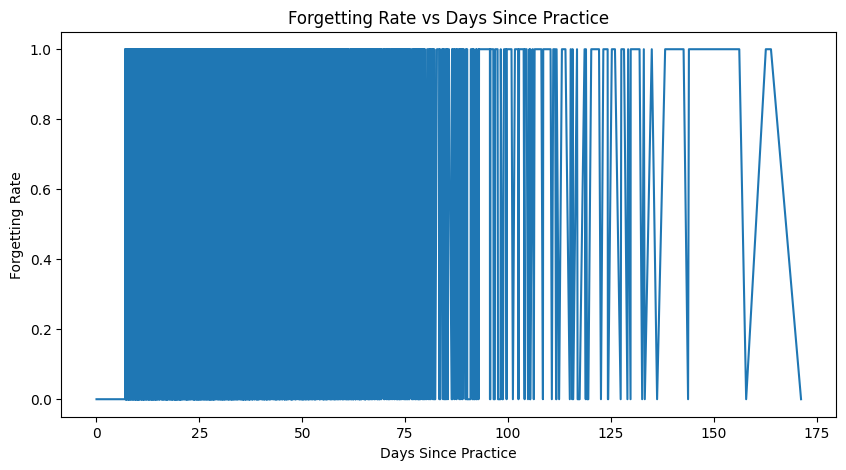

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(
    forgetting_by_gap["days_since_practice"],
    forgetting_by_gap["forgetting_event"]
)

plt.xlabel("Days Since Practice")
plt.ylabel("Forgetting Rate")
plt.title("Forgetting Rate vs Days Since Practice")

plt.show()

In [18]:
concept_forgetting = (
    df.groupby("concept")["forgetting_event"]
    .mean()
    .sort_values(ascending=False)
)

print(concept_forgetting)

concept
SUBQUERIES             0.629187
INDEXING               0.609170
TRANSACTIONS           0.605505
TRIGGERS               0.590631
INNER JOIN             0.571749
NORMALIZATION          0.570715
STORED PROCEDURES      0.565116
UNION                  0.559486
GROUP BY               0.544492
JOINS                  0.539711
RIGHT JOIN             0.531828
HAVING                 0.527988
LEFT JOIN              0.523810
FOREIGN KEY            0.513292
ORDER BY               0.512671
AGGREGATE FUNCTIONS    0.508368
PRIMARY KEY            0.479339
VIEWS                  0.474878
SELECT                 0.474277
WHERE                  0.462662
Name: forgetting_event, dtype: float64


## 4.9 — Prepare features

In [19]:
feature_columns = [
    "concept",
    "difficulty",
    "time_gap_days",
    "days_since_practice",
    "student_prior_attempts",
    "student_prior_accuracy",
    "concept_prior_attempts",
    "concept_prior_accuracy"
]

X = df[feature_columns]

y = df["forgetting_event"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 8)
y shape: (10000,)


## 4.10 — Train/test split

In [20]:
train_mask = df["attempt"] <= 80

X_train = X[train_mask]
X_test = X[~train_mask]

y_train = y[train_mask]
y_test = y[~train_mask]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8000
Testing samples: 2000


In [21]:
print("Training forgetting distribution:")
print(y_train.value_counts())

print("\nTesting forgetting distribution:")
print(y_test.value_counts())

Training forgetting distribution:
forgetting_event
1    4245
0    3755
Name: count, dtype: int64

Testing forgetting distribution:
forgetting_event
1    1101
0     899
Name: count, dtype: int64


In [22]:
print("\nTraining percentages:")
print(
    y_train.value_counts(normalize=True) * 100
)

print("\nTesting percentages:")
print(
    y_test.value_counts(normalize=True) * 100
)


Training percentages:
forgetting_event
1    53.0625
0    46.9375
Name: proportion, dtype: float64

Testing percentages:
forgetting_event
1    55.05
0    44.95
Name: proportion, dtype: float64


## 4.12 — Build the Forgetting Prediction model

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [24]:
categorical_features = [
    "concept"
]

In [25]:
numerical_features = [
    "difficulty",
    "time_gap_days",
    "days_since_practice",
    "student_prior_attempts",
    "student_prior_accuracy",
    "concept_prior_attempts",
    "concept_prior_accuracy"
]

## processing

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore" ), categorical_features),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

## model

In [27]:
forgetting_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

## 4.13 — Train

In [28]:
forgetting_model.fit(
    X_train,
    y_train
)

print(
    "Forgetting prediction model trained successfully!"
)

Forgetting prediction model trained successfully!


## 4.14 — Make predictions

In [29]:
forgetting_pred = forgetting_model.predict(
    X_test
)

forgetting_probability = (
    forgetting_model
    .predict_proba(X_test)[:, 1]
)

print("Predictions:")
print(forgetting_pred[:20])

print("\nForgetting probabilities:")
print(
    forgetting_probability[:20]
)

Predictions:
[1 0 1 0 0 1 1 0 1 0 0 0 1 0 0 0 1 0 0 1]

Forgetting probabilities:
[0.67558719 0.36539833 0.73745515 0.46969602 0.44892084 0.79943013
 0.50939649 0.39962569 0.63637735 0.49599613 0.43844818 0.43429205
 0.61517172 0.41363675 0.33645534 0.455912   0.71357802 0.32773085
 0.46662433 0.96575249]


In [30]:
print(df["forgetting_event"].value_counts())

forgetting_event
1    5346
0    4654
Name: count, dtype: int64


In [31]:
print(
    df.groupby("days_since_practice")[
        "forgetting_event"
    ].mean()
)

days_since_practice
0.006      0.0
0.008      0.0
0.010      0.0
0.011      0.0
0.013      0.0
          ... 
156.214    1.0
157.888    0.0
162.665    1.0
163.914    1.0
171.227    0.0
Name: forgetting_event, Length: 9094, dtype: float64


In [32]:
print(forgetting_probability[:20])

[0.67558719 0.36539833 0.73745515 0.46969602 0.44892084 0.79943013
 0.50939649 0.39962569 0.63637735 0.49599613 0.43844818 0.43429205
 0.61517172 0.41363675 0.33645534 0.455912   0.71357802 0.32773085
 0.46662433 0.96575249]


## Evaluate the model

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(
    y_test,
    forgetting_pred
)

precision = precision_score(
    y_test,
    forgetting_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    forgetting_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    forgetting_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    forgetting_probability
)

print("========== FORGETTING MODEL ==========")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

========== FORGETTING MODEL ==========
Accuracy : 0.686
Precision: 0.7069
Recall   : 0.7339
F1 Score : 0.7201
ROC-AUC  : 0.7297


## 4.18 — Define Forgetting Risk Levels

In [35]:
forgetting_results = X_test.copy()

forgetting_results["actual_forgetting"] = y_test.values

forgetting_results["forgetting_probability"] = (
    forgetting_probability
)

forgetting_results["predicted_forgetting"] = (
    forgetting_pred
)

In [36]:
def risk_level(probability):
    if probability >= 0.70:
        return "High"
    elif probability >= 0.40:
        return "Medium"
    else:
        return "Low"


forgetting_results["risk_level"] = (
    forgetting_results["forgetting_probability"]
    .apply(risk_level)
)

In [37]:
forgetting_results.head(20)

,concept,difficulty,time_gap_days,days_since_practice,student_prior_attempts,student_prior_accuracy,concept_prior_attempts,concept_prior_accuracy,actual_forgetting,forgetting_probability,predicted_forgetting,risk_level
80,RIGHT JOIN,0.600,0.475,47.727,80,0.337500,6,0.000000,1,0.675587,1,Medium
81,PRIMARY KEY,0.283,0.162,10.097,81,0.333333,4,1.000000,1,0.365398,0,Low
82,FOREIGN KEY,0.458,2.648,41.661,82,0.329268,2,0.500000,1,0.737455,1,High
83,INNER JOIN,0.522,2.937,6.815,83,0.325301,5,0.200000,0,0.469696,0,Medium
84,WHERE,0.430,0.634,20.863,84,0.321429,9,0.555556,1,0.448921,0,Medium
85,TRIGGERS,0.737,0.868,51.308,85,0.317647,3,0.000000,1,0.799430,1,High
86,SELECT,0.344,0.922,23.441,86,0.313953,6,0.333333,1,0.509396,1,Medium
87,AGGREGATE FUNCTIONS,0.338,1.776,11.380,87,0.310345,3,0.666667,1,0.399626,0,Low
88,ORDER BY,0.241,0.842,37.258,88,0.306818,3,1.000000,0,0.636377,1,Medium
89,VIEWS,0.618,1.903,20.102,89,0.314607,7,0.142857,1,0.495996,0,Medium


In [38]:
print(
    forgetting_results["risk_level"]
    .value_counts()
)

risk_level
Medium    1104
High       513
Low        383
Name: count, dtype: int64


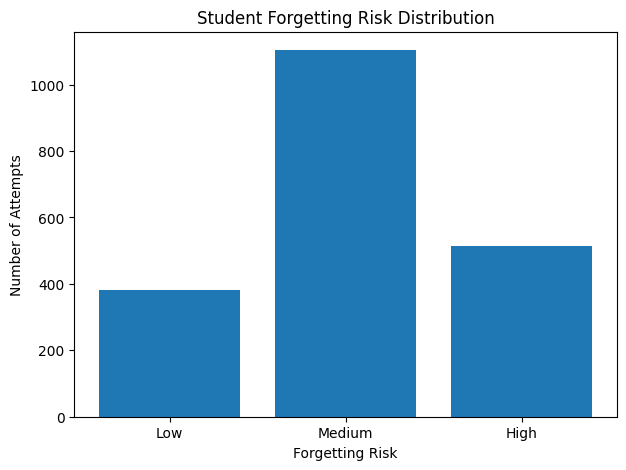

In [39]:
risk_counts = (
    forgetting_results["risk_level"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
)

plt.figure(figsize=(7, 5))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.xlabel("Forgetting Risk")
plt.ylabel("Number of Attempts")
plt.title("Student Forgetting Risk Distribution")

plt.show()

## 4.20 — Find High-Risk Concepts

In [40]:
high_risk_concepts = (
    forgetting_results
    .groupby("concept")
    ["forgetting_probability"]
    .mean()
    .sort_values(ascending=False)
)

print(high_risk_concepts)

concept
TRANSACTIONS           0.698772
UNION                  0.658979
SUBQUERIES             0.653855
INDEXING               0.640546
GROUP BY               0.611803
TRIGGERS               0.605990
INNER JOIN             0.599900
AGGREGATE FUNCTIONS    0.591496
NORMALIZATION          0.589553
STORED PROCEDURES      0.588964
JOINS                  0.582823
FOREIGN KEY            0.563772
RIGHT JOIN             0.556192
PRIMARY KEY            0.549890
ORDER BY               0.548223
LEFT JOIN              0.537753
HAVING                 0.536861
SELECT                 0.527525
VIEWS                  0.527028
WHERE                  0.494560
Name: forgetting_probability, dtype: float64


## 4.21 — Visualize Concept Forgetting Risk

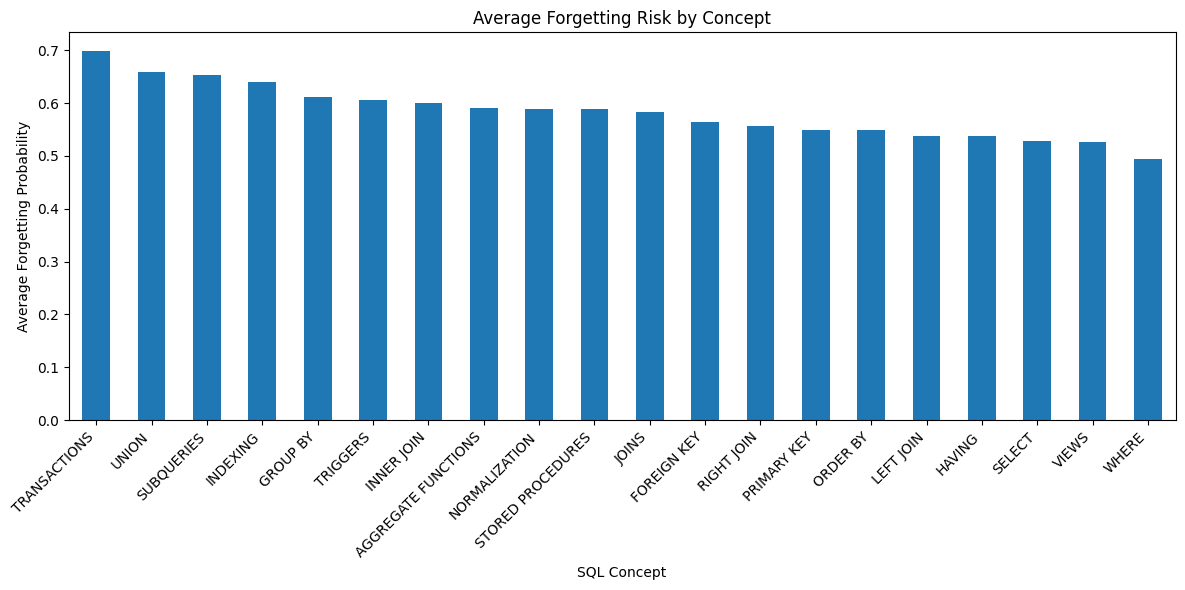

In [41]:
plt.figure(figsize=(12, 6))

high_risk_concepts.plot(
    kind="bar"
)

plt.xlabel("SQL Concept")
plt.ylabel("Average Forgetting Probability")
plt.title("Average Forgetting Risk by Concept")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

## 4.22 — Save the model

In [42]:
import joblib

joblib.dump(
    forgetting_model,
    "learntwin_forgetting_model.pkl"
)

print(
    "Forgetting model saved successfully!"
)

Forgetting model saved successfully!


## Student history
  ##    ↓
## How long since practice?
   ##   ↓
## Previous concept performance
   ##   ↓
## Forgetting ML model
##      ↓
## Forgetting probability
   ##  ↓
## LOW / MEDIUM / HIGH risk

In [43]:
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.686
Precision: 0.7069
Recall   : 0.7339
F1 Score : 0.7201
ROC-AUC  : 0.7297
